In [1]:
import matplotlib.pyplot as plt
import numpy as np
from numpy import log as ln
from numpy import log10 as log
from numpy import exp as exp
from scipy.optimize import dual_annealing
from scipy.optimize import minimize
from random import uniform, randint
from statistics import mean, stdev
import time
import os
import emcee
import corner
import math
import warnings
from multiprocessing.pool import Pool
from multiprocessing import get_start_method
from multiprocessing import get_context

In [2]:
#CLEAN UP FROM PREVIOUS RUN...
#Delte the progress.txt file containing intermediate values for the cost function during
#the simulated annealing algorithm
try:
    os.remove("progress.txt")
    print('Removed existing progress.txt file')
except OSError:
    pass


Removed existing progress.txt file


Opening initial_atm_vMCMC_2024.txt...
  Input file length =  69



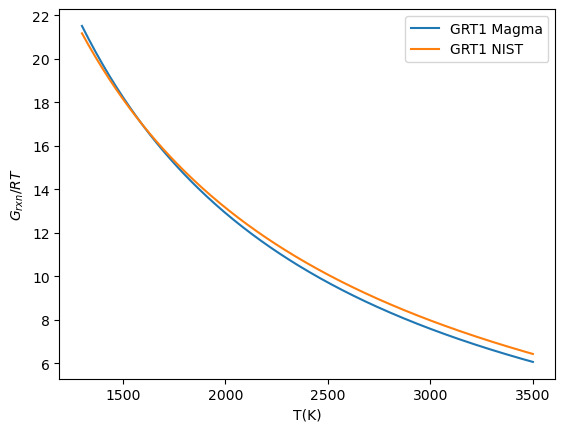

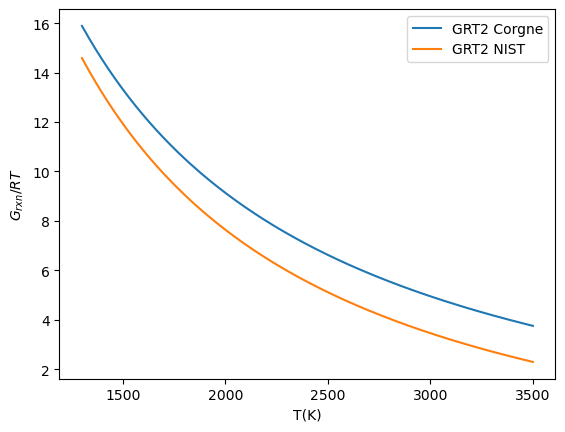

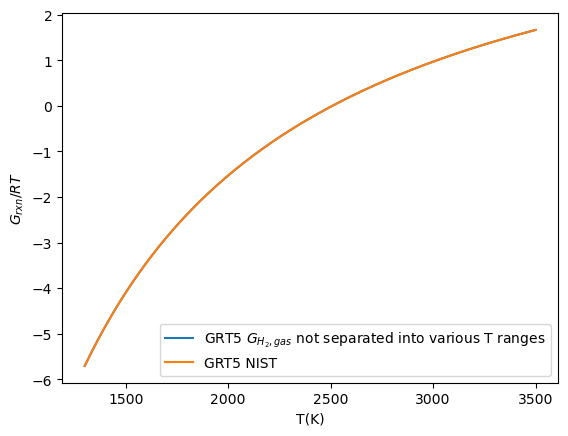

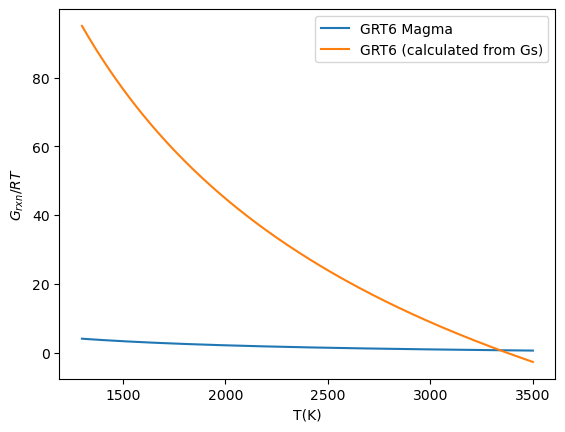

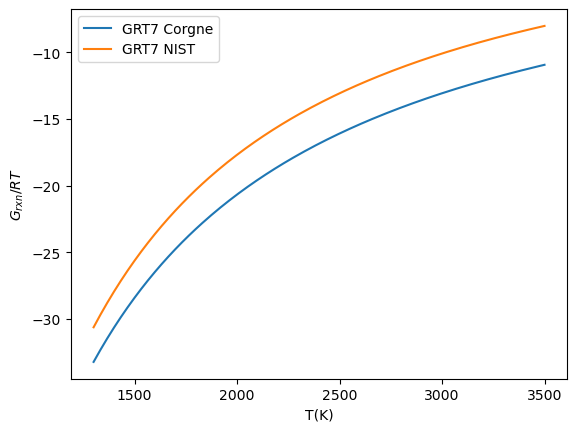

Selected surface temperature= 3500.0 K
Temperature used = 3488.9447236180904 K
Core temperature for rxns 2, 4, 5, and 7 =  3500.0

Weight for mass balance equations = 1.5
Weight for summing constraints = 0.5
Weight for atmosphere rxns = 1.0
Weight for solubility rxns = 1.0
Weight for intra-melt rxns = 5.0
Weight for evaporation rxns = 5.0
weight for f 1 =  1.0    Na2SiO3 = Na2O + SiO2
weight for f 2 =  1.0    1/2SiO2 + Fe = FeO + 1/2Si
weight for f 3 =  1.0    MgSiO3 = MgO + SiO2
weight for f 4 =  1.0    O + 1/2Si = 1/2SiO2
weight for f 5 =  1.0    2Hmetal=H2,sil
weight for f 6 =  1.0    FeSiO3 = FeO + SiO2
weight for f 7 =  2.0    2H2O,sil + Si=SiO2 + 2H2,sil
weight for f 8 =  1.0    CO,g + 1/2O2 = CO2,g
weight for f 9 =  1.0    CH4,g + 1/2O2 = 2H2,g + CO,g
weight for f 10 =  5.0    H2,g + 1/2O2 = H2O,g
weight for f 11 =  1.0    FeO = Fe,g + 1/2O2
weight for f 12 =  1.0    MgO = Mg,g + 1/2O2
weight for f 13 =  1.0    SiO2 = SiO,g + 1/2O2
weight for f 14 =  1.0    Na2O = 2Na,g + 1/2O2


In [3]:
%run Equations.ipynb

In [4]:
#Input seed value from file
nseed_prov=int(values[65])

#Assign iterations per temperature for sim annealing
iter=int(values[66])
print('')
print('Number of iterations =',iter)

#Assign a value for the offset between walkers for the MCMC search, e.g. 1e-9 is a common value
ranoffset=float(values[67])
print('')
print('Offset for walkers = %10.3e' %ranoffset)


Number of iterations = 2000

Offset for walkers =  1.000e-06


In [5]:
#Initial value for cost (or objective) function, can use 1.2x this value for the initial_temp in dual_annealing below
cost=func(var)
print('')
print('Initial objective function =',cost)


Initial objective function = 7545084672.652569


Mean Objective function at start = 150580779244859.53
Std deviation of smoothed Objective function at start = 56056188514225.42
Estimated initial search T = 2774686958198636.5


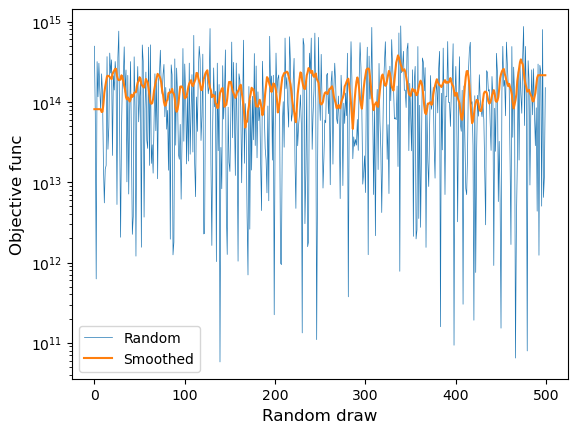

Initial annealing T = 2774686958198636.5
Working..........



In [6]:
#Estimate the mean cost function by sampling values
num_test=500
cost_estimates=np.zeros(num_test)
var_random=np.zeros(numvar)
for k in range(0,num_test):
    for i in range(0,numvar):
        var_random[i]=uniform(bounds[i,0],bounds[i,1])
#        print('var', i, '=',var_random[i])
    cost_estimates[k]=func(var_random)
#    print('test random cost values =',cost_estimates)

cost_smoothed=smoothTriangle(cost_estimates, 5)

mean_cost=mean(cost_smoothed)
sigma_cost=stdev(cost_smoothed)

print('Mean Objective function at start =',mean_cost)
print('Std deviation of smoothed Objective function at start =',sigma_cost)

#CALCULATE INITIAL SEARCH TEMPERATURE based on % probability of accepting uphill;
#The probability for accepting uphill results is the argument to the ln ... usually 0.8
T_estimate=-sigma_cost/ln(0.98)
print('Estimated initial search T =',T_estimate)

plt.plot(cost_estimates,label='Random',linewidth=0.5)
plt.plot(cost_smoothed,label='Smoothed')
plt.ylabel('Objective func', fontsize=12)
plt.xlabel('Random draw',fontsize=12)
plt.yscale('log')
plt.legend()
plt.show(block=False)  #Permit execution to continue with plot open
plt.pause(7) #Pause x seconds before moving on
plt.close()

Tini=T_estimate
#Tini=100.0
print('Initial annealing T =',Tini)
print('Working..........')
print('')


Seed for search = 410


D:\Anaconda\Lib\site-packages\scipy\optimize\_dual_annealing.py:120: RuntimeWarning: overflow encountered in exp
  x *= np.exp(-(self._visiting_param - 1.0) * np.log(



solution for parameters x =  message: ['Maximum number of iteration reached']
 success: True
  status: 0
     fun: 16029.699837140954
       x: [ 2.058e-01  6.702e-02 ...  3.532e+03  8.954e+02]
     nit: 2000
    nfev: 169281
    njev: 1776
    nhev: 0
 Objective function end/start = 1.0645249624505559e-10


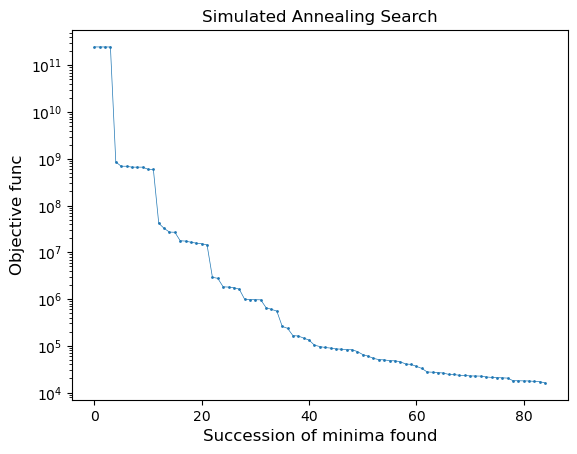

Plot of simulated annealing minima saved as progress.png



In [7]:
#PERFORM MINIMIZATION OF func(var) TO OBTAIN SOLUTION
#
#INVOKE SIMULATED ANNEALING...visit parameter controls cooling, default visit=2.62, I use 2.985,
#larger values cool fast early (max=3), then flattens;
# restart_temp_ratio is the temperature value that triggers reannealing, 0 to 1;
# default initial_temp=5230.0, max initial temp is 5e4, should be 4x variance in cost function;
# max number of function calls, maxfun (default = 1e7), overrides number of iterations if breached;
# accept ranges from -5 to -10000, -500 works well, lower means lower prob of acceptance;
# seed selects a random number for the seed and reports the seed to the user;
# no_local_search=True causes classical simulated annealing with no local search strategy.
nseed=nseed_prov
if nseed_prov == 0:
    nseed=randint(1,500)
print('Seed for search =',nseed)
soln=dual_annealing(func,bounds,maxiter=iter,initial_temp=Tini,visit=2.98,maxfun=100000000, seed=nseed,\
    accept=-500.0,restart_temp_ratio=1.0e-9,callback=progressF)
print('')
print("solution for parameters x =",soln)
#solution contained in soln.x

quality=soln.fun/mean_cost
print(" Objective function end/start =",quality)

#Plot cost function at minima found during simulated annealing...
name='progress.txt'
values=np.genfromtxt(name,'float',delimiter="")  #Very useful function in numpy
cost_values=values

plt.plot(cost_values,linewidth=0.5,marker='o',markersize=1,markerfacecolor='white')
plt.title('Simulated Annealing Search')
plt.ylabel('Objective func', fontsize=12)
plt.yscale("log")
plt.xlabel('Succession of minima found',fontsize=12)
plt.show(block=False)  #Permit execution to continue with plot open
plt.pause(10) #Pause x seconds before moving on
plt.savefig('progress.png')
plt.close()

print('Plot of simulated annealing minima saved as progress.png')
print('')


In [8]:
# MCMC SEARCH STARTING WITH SIMULATED ANNEALING RESULT IN soln.x
# In this section, the parameters, mole fractions etc., comprising the model are stored in vector theta, while
# the model itself is considered to be the equilibrium constants and mass-balance constraints. They have the same
# dimensions since we are solving a system of equations equal to the number of unknowns.
print('')
print('MCMC Search beginning....')
print('')
theta=np.zeros(numvar)
theta=soln.x #Current estimate of best parameters from simulated annealing is assigned to model vector theta


MCMC Search beginning....



In [9]:
data

(array([-6.09129104e+00, -3.75156900e+00, -2.45931492e+00,  4.97720215e+00,
        -1.66493429e+00, -5.97246067e-01,  1.09264110e+01,  9.33360955e+00,
         1.44879202e+01,  1.66605590e+00, -1.04546525e+00, -1.19382427e+00,
         1.64438203e+00,  9.43518235e+00, -1.25001885e+01, -1.34748207e+01,
        -1.56828888e+01, -1.45842765e+01,  1.84720000e+03,  1.90620000e+03,
         5.62090002e+03,  1.78400000e+03,  4.59540002e+03,  3.20000023e+01,
         2.30000860e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
         0.00000000e+00]),
 array([3.04564552e-02, 1.87578450e-02, 1.22965746e-02, 2.48860107e-02,
        8.32467143e-03, 2.98623033e-03, 5.46320548e-02, 4.66680477e-02,
        7.24396011e-02, 8.33027950e-03, 5.22732624e-03, 5.96912133e-03,
        8.22191014e-03, 4.71759117e-02, 6.25009423e-02, 6.73741034e-02,
        7.84144441e-02, 7.29213826e-02, 1.84720000e-01, 1.90620000e-01,
        5.62090002e-01, 1.78400000e-01, 4.59540002e-01, 3.20000023e-03,
        2

In [10]:
# Print current model (not parameters) before starting MCMC
print('y(current model)= \n',model(soln.x))
print('')
print('yerr(errors for model)= \n ',yerr)
print('')


y(current model)= 
 [-5.16206575e+00 -2.99311977e+00 -3.12765864e+00  4.90111560e+00
 -3.00706965e-01 -1.27889107e+00  1.09759991e+01  6.87713943e+00
  1.89006685e+01  2.66847267e+00 -1.28750312e+00 -7.01954018e-01
  9.62285814e-01  9.73604988e+00 -6.94776151e+00 -6.56734262e+00
 -1.28016869e+01 -1.25727929e+01  1.55858716e+03  1.98675959e+03
  5.65409185e+03  1.57029169e+03  4.57665894e+03  3.28626493e+01
  2.42130120e+00  1.00021343e+00  1.00094639e+00  1.00805300e+00
  3.35373662e+00]

yerr(errors for model)= 
  [3.04564552e-02 1.87578450e-02 1.22965746e-02 2.48860107e-02
 8.32467143e-03 2.98623033e-03 5.46320548e-02 4.66680477e-02
 7.24396011e-02 8.33027950e-03 5.22732624e-03 5.96912133e-03
 8.22191014e-03 4.71759117e-02 6.25009423e-02 6.73741034e-02
 7.84144441e-02 7.29213826e-02 1.84720000e-01 1.90620000e-01
 5.62090002e-01 1.78400000e-01 4.59540002e-01 3.20000023e-03
 2.30000860e-04 1.00000000e-05 1.00000000e-05 1.00000000e-05
 1.00000000e-01]



In [11]:
# INPUT MCMC PARAMETERS: Set number of independent Markov chain walkers and iterations
nwalkers=200 #100

# Utilize thin for emcee to return every thin'th sample, add thin_by=thin to smapler.run_mcmc options
thin=10
niter=1000000 #2000000 works
niter_eff = int(niter/thin) # emcee does niter*thin iteractions, so correct for this to save time if using thin
        
# p0 is the array of initial positions for each walker, i.e., each separate
# Markov chain operating slightly displaced at random from one another.
# The code below creates an array of arrays with slightly purturbed locations
# in parameter space based on random draws from a multivariate Gaussian for
# these variables. Increase the prefix multiplier for random position offsets if the error
# "Initial state has a large condition number" is returned from emcee, indicating
# walkers are not sufficiently independent.
n=numvar
p0=[(theta)+ranoffset*np.random.randn(n) for i in range(nwalkers)]  #+1.0e-9*np.random.randn(n)

In [12]:
# RUN THE SEARCH....this one line of code initiates the search
sampler, pos, prob, state = main(p0,nwalkers,niter,n,lnprob,data)
print('')
print('...MCMC search completed.')

ValueError: cannot find context for 'fork'

In [ ]:
# EXPLORE results...
#position contains the parameter position (i.e, values) for each walker at the end of search
#print("Position of each sampler = ",pos)

# Concatenate all walker results into a single chain, array is (nwalkers*iterations x n(variables))
# or said another way, each row is a test position, each column is a variable.
samples=sampler.flatchain
posteriors=sampler.flatlnprobability

print('memory required for chain = ', samples.size * samples.itemsize)

In [ ]:
# Find dimensions of the returned data for the chains
print('sampler.flatchain shape = ',np.shape(samples))
print('sampler.flatlnprobability shape = ',np.shape(posteriors))

# Select as your best set of parameters theta in the sampler that has the greatest posterior probability
# by interrogating the ln probability for each sample, also concatenated from all walkers
result=samples[np.argmax(sampler.flatlnprobability)]

# Best-fit final model consisting of equilibrium constants, total moles of components, and mole fraction sums
best_fit_model = model(result)

In [ ]:
# Calculate goodness of fit for this best-fit model
chi_square=sum(((y-best_fit_model)**2.0)/yerr**2.0)
red_chi_square=chi_square/(float(count)-float(n))
print('')
print('[Reduced chi-squared for fit] = %10.6e' %red_chi_square)
print('')
print('New y (new calculated model)= \n ',best_fit_model)
print('')

#COMPARE parameters from simulated annealing with MCMC, latter stored in result
refinement=result-soln.x
print('')
print('Differences in model parameters =',refinement)

In [ ]:
grams_per_mole_silicate=0.000
for i in range(0,11):
    grams_per_mole_silicate=grams_per_mole_silicate+result[i]*mol_wts[i]

New_Press=result[28]


In [ ]:
#print(result)  #reprint entire solution array
print('')
xMgO_melt=result[0]
print('xMgO_silicate =',xMgO_melt)
xSiO2_melt=result[1]
print('xSiO2_silicate =',xSiO2_melt)
xMgSiO3_melt=result[2]
print('xMgSiO3_silicate =',xMgSiO3_melt)
xFeO_melt=result[3]
print('xFeO_silicate =',xFeO_melt)
xFeSiO3_melt=result[4]
print('xFeSiO3_silicate =',xFeSiO3_melt)
xNa2O_melt=result[5]
print('xNa2O_silicate =',xNa2O_melt)
xNa2SiO3_melt=result[6]
print('xNa2SiO3_silicate =',xNa2SiO3_melt)
xH2_melt=result[7]
print('xH2_silicate =',xH2_melt)
xH2O_melt=result[8]
print('xH2O_silicate =', xH2O_melt)
xCO_melt=result[9]
print('xCO_silicate =', xCO_melt)
xCO2_melt=result[10]
print('xCO2_silicate =', xCO2_melt)
melt_sum=0.0
for i in range(0,11):
    melt_sum=melt_sum+result[i]
print('Mole_fraction_sum_for_melt = ',melt_sum)


In [ ]:
#H2/H2O molecular for silicate and apparent DIW fO2
xH2_xH2O_silicate=result[7]/result[8]
print('')
print('xH2/xH2O silicate =',xH2_xH2O_silicate)
DIW_apparent=2.0*log((result[3]+result[4])/0.85)
DIW_actual=2.0*log((result[3]+result[4]/result[11]))
print('DIW_silicate_for_xFe_metal=0.85 =',DIW_apparent)
print('DIW_actual = ',DIW_actual)


In [ ]:
#Convert silicate to wt% oxides etc.
print('')
print("grams_per_mole_silicate =", grams_per_mole_silicate)
wtpercentSiO2=100.0*(result[1]+result[2]+result[4])*mol_wts[1]/grams_per_mole_silicate
print('Wt_%_SiO2_(total Si)_silicate =',wtpercentSiO2)
wtpercentMgO=100.0*(result[0]+result[2])*mol_wts[0]/grams_per_mole_silicate
print('Wt_%_MgO_(total Mg)_silicate =',wtpercentMgO)
wtpercentFeO=100.0*(result[3]+result[4])*mol_wts[3]/grams_per_mole_silicate
print('Wt_%_FeO_(total Fe)_silicate =',wtpercentFeO)
wtpercentNa2O=100.0*(result[5]+result[6])*mol_wts[5]/grams_per_mole_silicate
print('Wt_%_Na2O_(total Na)_silicate =',wtpercentNa2O)
wtpercentHmelt=100.0*(result[7])*mol_wts[7]/grams_per_mole_silicate
print('Wt_%_H2_melt =',wtpercentHmelt)
wtpercentH2Omelt=100.0*(result[8])*mol_wts[8]/grams_per_mole_silicate
print('Wt_%_H2O_melt =',wtpercentH2Omelt)
wtpercentCOmelt=100.0*(result[9])*mol_wts[9]/grams_per_mole_silicate
print('Wt_%_CO_melt =',wtpercentCOmelt)
wtpercentCO2melt=100.0*(result[10])*mol_wts[10]/grams_per_mole_silicate
print('Wt_%_CO2_melt =',wtpercentCO2melt)

In [ ]:
xFe_metal=result[11]
print('xFe_metal =',xFe_metal)
xSi_metal=result[12]
print('xSi_metal =',xSi_metal)
xO_metal=result[13]
print('xO_metal =', xO_metal)
xH_metal=result[14]
print('xH_metal =',xH_metal)
metal_sum=xFe_metal+xSi_metal+xO_metal+xH_metal
print('Mole_fraction_sum_for_metal = ',metal_sum)

In [ ]:
#Convert metal to weight %
print('')
grams_per_mole_metal=result[11]*55.847+result[12]*28.0855+result[13]*15.9994+result[14]*1.00794
wtpercentFe=result[11]*55.847/grams_per_mole_metal
wtpercentFe=wtpercentFe*100.0
print('grams_per_mole_metal =',grams_per_mole_metal)
print('Wt_%_Fe_metal =', wtpercentFe)
wtpercentSi=result[12]*28.0855/grams_per_mole_metal
wtpercentSi=wtpercentSi*100.0
print('Wt_%_Si_metal =', wtpercentSi)
wtpercentO=result[13]*15.9994/grams_per_mole_metal
wtpercentO=wtpercentO*100.0
print('Wt_%_O_metal =', wtpercentO)
wtpercentH=result[14]*1.00794/grams_per_mole_metal
wtpercentH=wtpercentH*100.0
print('Wt_%_H_metal =', wtpercentH)

In [ ]:
print('')
xH2_gas=result[15]
print('xH2_atm =',xH2_gas)
xCO_gas=result[16]
print('xCO_atm =',xCO_gas)
xCO2_gas=result[17]
print('xCO2_atm =',xCO2_gas)
xCH4_gas=result[18]
print('xCH4_atm =',xCH4_gas)
xO2_gas=result[19]
print('xO2_atm =',xO2_gas)
xH2O_gas=result[20]
print('xH2O_atm =',xH2O_gas)
xFe_gas=result[21]
print('xFe_atm =',xFe_gas)
xMg_gas=result[22]
print('xMg_atm =',xMg_gas)
xSiO_gas=result[23]
print('xSiO_atm =',xSiO_gas)
xNa_gas=result[24]
print('xNa_atm =',xNa_gas)
gas_sum=0.0
for i in range(15,25):
    gas_sum=gas_sum+result[i]
print('Mole_fraction_sum_for_atm = ',gas_sum)

In [ ]:
#H2/H2O molecular for atmosphere
xH2_xH2O_atm=result[15]/result[20]
print('xH2/xH2O atmosphere =',xH2_xH2O_atm)
##IW fO2 buffer curve using molten FeO and Fe so that the activities
## must refer to activities in the molten phases relative to the pure
## molten phases.
GIW=0.5*GgasO2[nT]+GmetalFe[nT]-GmeltFeO[nT]
logKIW=-GIW/(Rgas*TK[nT]*log_to_ln)
#For unit activities in the oxide and metal melts, the KIW defines an
#an equilibrium pressure of O2 such that (PO2/Pstd)=Keq^2.  The ratio
#of pressures is the correction from actual PO2 to pure O2 at P std.
#If Pstd state is 1 bar, then this PO2 is pressure of pure O2 in bar.
KIW=10.0**logKIW
PO2IW=KIW**2.0
logPO2IW=log(PO2IW)
logPO2atm=log(result[19]*New_Press) #PO2 in bar relative to std state of 1 bar
DIW_atm=logPO2atm-logPO2IW
print('DIW_atmosphere =',DIW_atm)

In [ ]:
#Grams per mole atmosphere
grams_per_mole_atm=result[15]*mol_wts[15]+result[16]*mol_wts[16]+\
    result[17]*mol_wts[17]+result[18]*mol_wts[18]+result[19]*mol_wts[19]+ \
    result[20]*mol_wts[20]+result[21]*mol_wts[21]+result[22]*mol_wts[22]+ \
    result[23]*mol_wts[23]+result[24]*mol_wts[24]
print('')
print('grams_per_mole_atmosphere = ',grams_per_mole_atm)
wtpercentH2atm=100.0*result[15]*mol_wts[15]/grams_per_mole_atm
print('Wt_%_H2_atmosphere =', wtpercentH2atm)
wtpercentCOatm=100.0*result[16]*mol_wts[16]/grams_per_mole_atm
print('Wt_%_CO_atmosphere =', wtpercentCOatm)
wtpercentCO2atm=100.0*result[17]*mol_wts[17]/grams_per_mole_atm
print('Wt_%_CO2_atmosphere =', wtpercentCO2atm)
wtpercentCH4atm=100.0*result[18]*mol_wts[18]/grams_per_mole_atm
print('Wt_%_CH4_atmosphere =', wtpercentCH4atm)
wtpercentO2atm=100.0*result[19]*mol_wts[19]/grams_per_mole_atm
print('Wt_%_O2_atmosphere =', wtpercentO2atm)
wtpercentH2Oatm=100.0*result[20]*mol_wts[20]/grams_per_mole_atm
print('Wt_%_H2O_atmosphere =', wtpercentH2Oatm)
wtpercentFeatm=100.0*result[21]*mol_wts[21]/grams_per_mole_atm
print('Wt_%_Fe_atmosphere =', wtpercentFeatm)
wtpercentMgatm=100.0*result[22]*mol_wts[22]/grams_per_mole_atm
print('Wt_%_Mg_atmosphere =', wtpercentMgatm )
wtpercentSiOatm=100.0*result[23]*mol_wts[23]/grams_per_mole_atm
print('Wt_%_SiO_atmosphere =', wtpercentSiOatm)
wtpercentNaatm=100.0*result[24]*mol_wts[24]/grams_per_mole_atm
print('Wt_%_Na_atmosphere =', wtpercentNaatm)

In [ ]:
print('')
print('Equilibrium_planet_composition:')
moles_atm=result[25]
print('  Moles_atm =',moles_atm)
moles_silicate=result[26]
print('  Moles_silicate = ',moles_silicate)
moles_metal=result[27]
print('  Moles_metal =',moles_metal)
molefrac_atm=moles_atm/(moles_atm+moles_silicate+moles_metal)
molefrac_silicate=moles_silicate/(moles_atm+moles_silicate+moles_metal)
molefrac_metal=1.0-molefrac_atm-molefrac_silicate
print('')
print('  Mole_fraction_atmosphere =',molefrac_atm)
print('  Mole_fraction_silicate =',molefrac_silicate)
print('  Mole_fraction_metal =',molefrac_metal)
print(' ')
grams_atm=molefrac_atm*grams_per_mole_atm  #actually grams_i/mole planet
grams_silicate=molefrac_silicate*grams_per_mole_silicate
grams_metal=molefrac_metal*grams_per_mole_metal
totalmass=grams_atm+grams_silicate+grams_metal
massfrac_atm=grams_atm/totalmass
massfrac_silicate=grams_silicate/totalmass
massfrac_metal=grams_metal/totalmass
print('  Mass_fraction_atmosphere =',massfrac_atm)
print('  Mass_fraction_silicate =',massfrac_silicate)
print('  Mass_fraction_metal =',massfrac_metal)

In [ ]:
#Estimate atmospheric pressure at the surface of the planet: fratio is the Matm/Mplanet mass ratio
#fratio=massfrac_atm/(1.0-massfrac_atm)
#New_Press=1.2e6*fratio*(Mplanet_Mearth)**(2.0/3.0)
print('')
print('  Mass_of_planet =',Mplanet_Mearth,'Earth masses')
print('  Estimated_surface_pressure =',New_Press,' bar')

In [ ]:
#Estimate nominal atmospheric pressure at the surface of the planet: fratio is the Matm/Mplanet mass ratio
fratio=massfrac_atm/(1.0-massfrac_atm)
Nominal_Press=1.2e6*fratio*(Mplanet_Mearth)**(2.0/3.0)
print('  Nominal_surface_pressure =',Nominal_Press,' bar')

In [ ]:
print('')
nSi_final=result[26]*(result[1]+result[2]+result[4]+result[6])+result[12]*result[27]+(result[23])*result[25] #Si
nMg_final=result[26]*(result[0]+result[2])+result[22]*result[25] #Mg
nO_final=(result[26]*(result[0]+2.0*result[1]+3.0*result[2]+result[3]+3.0*result[4]+result[5]+3.0*result[6]+result[8]+result[9]+2.0*result[10]) \
    + result[27]*result[13]+result[25]*(result[23]+2.0*result[17]+2.0*result[19]+result[20]+result[16]) ) #O
nFe_final=result[26]*(result[3]+result[4])+result[27]*result[11]+result[25]*result[21] #Fe
nH_final=result[27]*result[14]+result[26]*(2.0*result[7]+2.0*result[8])+result[25]*(2.0*result[15]+2.0*result[20]+4.0*result[18]) #H
nNa_final=result[26]*(2.0*result[5]+2.0*result[6])+result[25]*result[24] #Na
nC_final=result[26]*(result[9]+result[10])+result[25]*(result[18]+result[17]+result[16]) #C

print('Mass balance checks:')
print('  Initial moles Si =',nSi)
print('  Final moles Si   =', nSi_final)
print('')
print('  Initial moles Mg =',nMg)
print('  Final moles Mg   =', nMg_final)
print('')
print('  Initial moles H  =',nH)
print('  Final moles H    =',nH_final)
print('')
print('  Initial moles O  =',nO)
print('  Final moles O    =',nO_final)
print('')
print('  Initial moles Fe =',nFe)
print('  Final moles Fe   = ',nFe_final)
print('')
print('  Initial moles Na =',nNa)
print('  Final moles Na   = ',nNa_final)
print('')
print('  Initial moles C =',nC)
print('  Final moles C   = ',nC_final)
print('')
print('Finished: Mole fractions and moles stored in final_atm.txt.')

In [ ]:
# POST-OPTIMIZATION TRIAGE - print deviations from equilibrium and mass balance
# Here KEQ includes mole fractions and pressures and so these are actual equilibrium constants....
KEQ=np.zeros(18)
K=np.zeros(18)
for i in range(0,18):
    KEQ[i]=exp(y[i])  # Thermodynamic equilibrium constants
    K[i]=exp(best_fit_model[i])  # Calculated equilibrium constants from mole fractions and pressures

# Mass balance for elements

f19_f=(nSi-(result[26]*(result[1]+result[2]+result[4]+result[6])+result[12]*result[27]+(result[23]])*result[25]))
f20_f=(nMg-(result[26]*(result[0]+result[2])+result[22]*result[25]))
f21_f=(nO-(result[26]*(result[0]+2.0*result[1]+3.0*result[2]+result[3]+3.0*result[4]+result[5]+3.0*result[6]+result[8]+result[9]+2.0*result[10]) \
        + result[27]*result[13]+result[25]*(result[23]+2.0*result[17]+2.0*result[19]+result[20]+result[16]) ))
f22_f=(nFe-(result[26]*(result[3]+result[4])+result[27]*result[11]+result[25]*result[21]))
f23_f=(nH-(result[27]*result[14]+result[26]*(2.0*result[7]+2.0*result[8])+result[25]*(2.0*result[15]+2.0*result[20]+4.0*result[18])))
f24_f=(nNa-(result[26]*(2.0*result[5]+2.0*result[6])+result[25]*result[24]))
f25_f=(nC-(result[26]*(result[9]+result[10])+result[25]*(result[18]+result[17]+result[16])))
    
# Summing constraint on mole fractions
f26_f=1.0-result[0]-result[1]-result[2]-result[3]-result[4]-result[5]-result[6]-result[7]-result[8]-result[9]-result[10]
f27_f=1.0-result[11]-result[12]-result[13]-result[14]
f28_f=1.0-result[15]-result[16]-result[17]-result[18]-result[19]-result[20]-result[21]-result[22]-result[23]-result[24]
print('')
print('Calculated KEQ vs. actual KEQ values:')
sum_thermo=0
for i in range(0,18):
    print("Rxn %.d KEQmodel = %10.3e vs KEQ = %10.3e " % ((i+1),K[i],KEQ[i]))
    sum_thermo=sum_thermo+abs(ln(K[i])-ln(KEQ[i]))
print('')
print('Sum abs(f1) to abs(f18), i.e. abs(ln(keq)-model values) =',sum_thermo)
print('')
print('Final deviations from mass balance:')
percentf19=100.0*f19_f/nSi
print("f19 = %10.6f (%6.3f %%) " %(f19_f, percentf19))

percentf20=100.0*f20_f/nMg
print("f20 = %10.6f (%6.3f %%) " %(f20_f, percentf20))

percentf21=100.0*f21_f/nO
print("f21 = %10.6f (%6.3f %%) " %(f21_f, percentf21))

percentf22=100.0*f22_f/nFe
print("f22 = %10.6f (%6.3f %%) " %(f22_f, percentf22))

percentf23=100.0*f23_f/nH
print("f23 = %10.6f (%6.3f %%) " %(f23_f, percentf23))

percentf24=100.0*f24_f/nNa
print("f24 = %10.6f (%6.3f %%) " %(f24_f, percentf24))

percentf25=100.0*f25_f/nC
print("f25 = %10.6f (%6.3f %%) " %(f25_f, percentf25))

sum_massbalance=abs(f19_f)+abs(f20_f)+abs(f21_f)+abs(f22_f)+abs(f23_f)+abs(f24_f)+abs(f25_f)
sum_moles=nSi+nMg+nO+nFe+nH+nNa+nC
percent_tot_moles=100.0*sum_massbalance/sum_moles
print("Sum abs(f19) to abs(f25) = %10.6f (%6.3f %%) " %(sum_massbalance, percent_tot_moles))
print('')

print('Final deviations from sum phase mole fractions = 1:')
percentf26=f26_f*100.0
print("f26 (mole frac silicate dev from 1) = %10.6f (%6.3f %%) " %(f26_f,percentf26))

percentf27=f27_f*100.0
print("f27 (mole frac metal dev from 1) = %10.6f (%6.3f %%) " %(f27_f,percentf27))

percentf28=f28_f*100.0
print("f28 (mole frac atm dev from 1) = %10.6f (%6.3f %%) " %(f28_f,percentf28))

sum_summing=abs(f26_f)+abs(f27_f)+abs(f28_f)
percent_summing=100.0*sum_summing/3.0
print("Sum abs(f26) to abs(f28) = %10.6f (%6.3f %%) " %(sum_summing, percent_summing))
print('')
print('')


In [ ]:
#Write summary of results to a file
a_file = open('output reproduction.txt', 'w')

a_file.write("%10.5e " %red_chi_square)
a_file.write('# Red chi-square of fit\n')

a_file.write("%10.5e " %Mplanet_Mearth)
a_file.write('# Planet mass in Earth masses\n')
a_file.write("%10.5e " %temp)
a_file.write('# Temperature K\n')
a_file.write("%10.5e " %New_Press)
a_file.write('# Pressure in bar\n')

a_file.write("%10.5e " %massfrac_atm)
a_file.write('# Mass fraction atmosphere\n')

a_file.write("%10.5e " %massfrac_silicate)
a_file.write('# Mass fraction silicate mantle\n')

a_file.write("%10.5e " %massfrac_metal)
a_file.write('# Mass fraction metal\n')

for i in range(0,numvar-1):
    a_file.write("%10.5e " % result[i])
    a_file.write("")
    a_file.write('# %s\n' %var_names[i])

a_file.write("%10.5e " %DIW_actual)
a_file.write('# DIW condensed planet rel to IW\n')

a_file.write("%10.5e " %wtpercentSiO2)
a_file.write('# wt percent SiO2 melt\n')
a_file.write("%10.5e " %wtpercentMgO)
a_file.write('# wt percent MgO melt\n')
a_file.write("%10.5e " %wtpercentFeO)
a_file.write('# wt percent FeO melt\n')
a_file.write("%10.5e " %wtpercentNa2O)
a_file.write('# wt percent Na2O melt\n')
a_file.write("%10.5e " %wtpercentHmelt)
a_file.write('# wt percent H2 melt\n')
a_file.write("%10.5e " %wtpercentH2Omelt)
a_file.write('# wt percent H2O melt\n')
a_file.write("%10.5e " %wtpercentCOmelt)
a_file.write('# wt percent CO melt\n')
a_file.write("%10.5e " %wtpercentCO2melt)
a_file.write('# wt percent CO2 melt\n')

a_file.write("%10.5e " %wtpercentFe)
a_file.write('# wt percent Fe metal\n')
a_file.write("%10.5e " %wtpercentSi)
a_file.write('# wt percent Si metal\n')
a_file.write("%10.5e " %wtpercentO)
a_file.write('# wt percent O metal\n')
a_file.write("%10.5e " %wtpercentH)
a_file.write('# wt percent H metal\n')
a_file.write("%10.5e " %density_core)
a_file.write('# Uncompressed density of metal g/cc\n')
a_file.write("%10.5e " %density_pure_iron)
a_file.write('# Uncompressed density of pure Fe g/cc\n')
a_file.write("%10.5e " %density_deficit)
a_file.write('# Experimental metal percent density deficit\n')

a_file.write("%10.5e " %grams_per_mole_atm)
a_file.write('# grams per mole atmosphere\n')
a_file.write("%10.5e " %wtpercentH2atm)
a_file.write('# wt percent H2 atm\n')
a_file.write("%10.5e " %wtpercentH2Oatm)
a_file.write('# wt percent H2O atm\n')
a_file.write("%10.5e " %wtpercentSiOatm)
a_file.write('# wt percent SiO atm\n')
a_file.write("%10.5e " %wtpercentMgatm)
a_file.write('# wt percent Mg atm\n')
a_file.write("%10.5e " %wtpercentFeatm)
a_file.write('# wt percent Fe atm\n')
a_file.write("%10.5e " %wtpercentNaatm)
a_file.write('# wt percent Na atm\n')
a_file.write("%10.5e " %wtpercentCOatm)
a_file.write('# wt percent CO atm\n')
a_file.write("%10.5e " %wtpercentCO2atm)
a_file.write('# wt percent CO2 atm\n')
a_file.write("%10.5e " %wtpercentCH4atm)
a_file.write('# wt percent CH4 atm\n')
a_file.write("%10.5e " %wtpercentO2atm)
a_file.write('# wt percent O2 atm\n')
a_file.write("%10.5e  " %DIW_atm)
a_file.write('# DIW atmosphere rel to IW\n')

for i in range(0,18):
    if i == 14:
        K14temp=K[i]/New_Press
        a_file.write("%10.5e  " %K14temp)
    else:
        a_file.write("%10.5e  " %K[i])
    a_file.write('# Model KEQ for rxn %d : %s \n' %((i+1),rxn_names[i+1]))
a_file.close()
print('')
# APPEND input file to the output_summary file
name_initial='initial reproduction.txt'
def copy_inputs(name_initial):
    count = len(open(name_initial).readlines())
    file_input=open(name_initial, 'r')
    Lines =file_input.readlines()
    afile = open('output reproduction.txt', 'a+')
    afile.write('\nINPUT FILE:\n')
    i=0
    while i < count:
        Newline=Lines[i].strip('\n')
    #    print(Newline)
        afile.write('%s \n' %Newline)
        i=i+1
    afile.close()
copy_inputs(name_initial)